Epoch 1: Weights=[ 0.39671415 -0.2382643 ], Bias=0.34768853810069256
Epoch 2: Weights=[ 0.29671415 -0.3382643 ], Bias=0.04768853810069254
Epoch 3: Weights=[ 0.29671415 -0.2382643 ], Bias=-0.052311461899307465
Epoch 4: Weights=[ 0.29671415 -0.1382643 ], Bias=-0.052311461899307465
Epoch 5: Weights=[ 0.29671415 -0.0382643 ], Bias=-0.052311461899307465
Epoch 6: Weights=[ 0.19671415 -0.0382643 ], Bias=-0.15231146189930747
Epoch 7: Weights=[0.19671415 0.0617357 ], Bias=-0.15231146189930747
Epoch 8: Weights=[0.19671415 0.1617357 ], Bias=-0.15231146189930747
Epoch 9: Weights=[0.19671415 0.0617357 ], Bias=-0.2523114618993075
Epoch 10: Weights=[0.19671415 0.0617357 ], Bias=-0.2523114618993075
Epoch 11: Weights=[0.19671415 0.0617357 ], Bias=-0.2523114618993075
Epoch 12: Weights=[0.19671415 0.0617357 ], Bias=-0.2523114618993075
Epoch 13: Weights=[0.19671415 0.0617357 ], Bias=-0.2523114618993075
Epoch 14: Weights=[0.19671415 0.0617357 ], Bias=-0.2523114618993075
Epoch 15: Weights=[0.19671415 0.0617

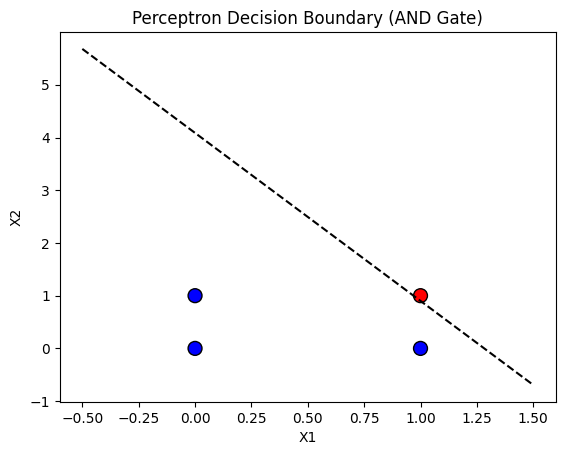

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# 1. Create Linearly Separable Dataset (AND Gate)
# ------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([0, 0, 0, 1])  # AND gate labels

# ------------------------
# 2. Perceptron Parameters
# ------------------------
np.random.seed(42)
weights = np.random.randn(2)
bias = np.random.randn()
lr = 0.1
epochs = 20

# Activation function (step)
def step_function(z):
    return np.where(z >= 0, 1, 0)

# ------------------------
# 3. Training Loop
# ------------------------
for epoch in range(epochs):
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        pred = step_function(z)
        error = y[i] - pred

        # Update rule
        weights += lr * error * X[i]
        bias += lr * error
    # Print progress
    print(f"Epoch {epoch+1}: Weights={weights}, Bias={bias}")
x1 = np.linspace(-0.5, 1.5, 100)
x2 = -(weights[0]*x1 + bias)/weights[1]

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100, edgecolors='k')
plt.plot(x1, x2, 'k--')
plt.title("Perceptron Decision Boundary (AND Gate)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [2]:
'''
Line-by-line explanation
import numpy as np
import matplotlib.pyplot as plt


Imports libraries:

numpy (as np) — numerical operations, arrays, dot products, random numbers.

matplotlib.pyplot (as plt) — plotting library for the scatter plot and decision boundary.

# ------------------------
# 1. Create Linearly Separable Dataset (AND Gate)
# ------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([0, 0, 0, 1])  # AND gate labels


X is a 4×2 numpy array containing all combinations of two binary inputs: (0,0), (0,1), (1,0), (1,1).

y is the corresponding labels for the AND gate: only (1,1) → 1; all others → 0.

Concept: AND is linearly separable — there exists a straight line in the 2D input space that separates points labeled 1 from those labeled 0. That guarantees a perceptron (linear classifier) can learn it.

# ------------------------
# 2. Perceptron Parameters
# ------------------------
np.random.seed(42)
weights = np.random.randn(2)
bias = np.random.randn()
lr = 0.1
epochs = 20


np.random.seed(42) — fixes the random seed so the random numbers (weights, bias) are reproducible each run. 42 is just a common example seed.

weights = np.random.randn(2) — initializes the two weights (one per input feature) with samples from a standard normal distribution (mean 0, variance 1).

bias = np.random.randn() — initializes the bias term (scalar) also from a standard normal.

lr = 0.1 — learning rate (η). Controls the step size when updating weights and bias.

epochs = 20 — number of full passes over the training set.

Concepts:

Random initialization is needed so weights aren't symmetric.

Learning rate affects stability and speed of learning.

The perceptron learns a linear decision surface: w·x + b = 0.

# Activation function (step)
def step_function(z):
    return np.where(z >= 0, 1, 0)


Defines the perceptron activation: a binary step function.

For input z (which is w·x + b), returns 1 if z >= 0, else 0.

np.where is vectorized and works efficiently on scalars or arrays.

Concept: The perceptron predicts class 1 when the linear score z is non-negative. This step is non-differentiable but classic perceptron learning uses a simple update rule that doesn't require gradients.

# ------------------------
# 3. Training Loop
# ------------------------
for epoch in range(epochs):
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        pred = step_function(z)
        error = y[i] - pred

        # Update rule
        weights += lr * error * X[i]
        bias += lr * error
    # Print progress
    print(f"Epoch {epoch+1}: Weights={weights}, Bias={bias}")


This block trains the perceptron. Step-by-step:

for epoch in range(epochs):

Outer loop: repeat training for epochs passes over the dataset.

for i in range(len(X)):

Inner loop: iterate through each training example (stochastic/online perceptron update).

z = np.dot(X[i], weights) + bias

Compute linear combination (w·x + b) for the i-th sample.

np.dot(X[i], weights) computes w0*x0 + w1*x1.

pred = step_function(z)

Apply the step activation to get predicted class 0 or 1.

error = y[i] - pred

Compute error (target minus predicted), which will be:

0 if correct,

1 if target is 1 but predicted 0 (false negative),

-1 if target is 0 but predicted 1 (false positive).

Update rule:

weights += lr * error * X[i]
bias += lr * error


This is the classic perceptron update:

Weights: w <- w + η * (y - ŷ) * x

Bias: b <- b + η * (y - ŷ)

If the prediction is correct (error=0) nothing changes.

If error = 1 (should be 1 but predicted 0): add η * x to weights (shifts decision boundary toward class 1).

If error = -1 (should be 0 but predicted 1): subtract η * x from weights (shifts boundary away from that region).

Because updates use X[i] which is binary (0 or 1), only the weights corresponding to input features equal to 1 get adjusted.

print(...) prints current weights and bias at the end of each epoch so you can watch convergence.

Concepts:

This online update is guaranteed to converge to a separating hyperplane in finite steps if the data are linearly separable (perceptron convergence theorem). AND is separable, so training should succeed.

The perceptron adjusts its linear boundary incrementally when mistakes occur.

x1 = np.linspace(-0.5, 1.5, 100)
x2 = -(weights[0]*x1 + bias)/weights[1]


These lines compute points to draw the decision boundary line w·x + b = 0.

Solve for x2 (y-axis) in terms of x1 (x-axis):

w0*x1 + w1*x2 + b = 0 → x2 = -(w0*x1 + b) / w1.

np.linspace(-0.5, 1.5, 100) creates 100 x1 points spanning a region slightly larger than the training data so the line is visible.

Important note: this divides by weights[1]. If weights[1] is (close to) zero, you'll get huge values or a division by zero. For robustness, check weights[1] before dividing in real code.

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100, edgecolors='k')
plt.plot(x1, x2, 'k--')
plt.title("Perceptron Decision Boundary (AND Gate)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100, edgecolors='k')

Plots the 4 data points.

X[:,0] and X[:,1] are the coordinates.

c=y colors the points by class: 0 or 1.

cmap='bwr' uses a blue-white-red colormap (so class 0 might be blue, class 1 red).

s=100 sets point size.

edgecolors='k' gives points black edges (sometimes produces a matplotlib warning for unfilled markers).

plt.plot(x1, x2, 'k--') draws the decision boundary line from the earlier x1,x2 calculation; 'k--' means black dashed line.

plt.title, plt.xlabel, plt.ylabel — add labels.

plt.show() displays the plot.

Concept: visually you should see the two classes separated by the learned line; for the AND gate, the single positive point (1,1) should lie on one side and the three 0s on the other.

Additional conceptual notes and tips

Why perceptron works here: The AND gate is linearly separable (you can draw a straight line separating (1,1) from the other three points). The perceptron algorithm will find such a line given enough updates and an appropriate learning rate.

Convergence guarantee: For linearly separable data, the perceptron learning rule converges in a finite number of updates (perceptron convergence theorem). For non-separable data, it will not converge but will keep updating.

Learning rate: lr only scales update magnitude. Too large → oscillations; too small → slow learning. For binary input AND, 0.1 is fine.

Bias role: The bias b translates the decision boundary away from the origin; without bias the line must pass through origin.

Initialization: Different random seeds produce different initialization so the number of epochs to converge may vary. np.random.seed(42) makes the run reproducible.

Numerical stability: When plotting x2, check weights[1] for near-zero to avoid division by zero.

Vectorized alternative: The inner loop currently processes single samples. You can also implement batch or vectorized updates, but classic perceptron uses online updates per example.

Limitations of perceptron: Perceptron can’t solve non-linearly separable problems (like XOR). For those, you need multilayer networks (e.g., a neural network with hidden units).

SyntaxError: incomplete input (ipython-input-1872609568.py, line 1)